# Детекция искусственно сгенерированных текстов

Задача: для каждого текста определить, написан ли он человеком 0 или сгенерирован моделью 1.

## 0. Подготовка

In [1]:
import os
import re
import math
import time
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem.snowball import SnowballStemmer

DATA_DIR = 'coat_data'
os.makedirs(DATA_DIR, exist_ok=True)

RNG_SEED = 42
np.random.seed(RNG_SEED)

## 1. Загрузка данных

In [2]:
BASE = 'https://huggingface.co/datasets/RussianNLP/coat/resolve/main/binary'
for split in ['train', 'validation']:
    path = os.path.join(DATA_DIR, f'{split}.parquet')
    if not os.path.exists(path):
        print(f'  downloading {split}...')
        urllib.request.urlretrieve(f'{BASE}/{split}-00000-of-00001.parquet', path)
    else:
        print(f'  cache hit   {split}.parquet')

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val   = pd.read_parquet(os.path.join(DATA_DIR, 'validation.parquet'))

print(f'\ntrain: {len(train):,} строк, label distribution: {train.label.value_counts().to_dict()}')
print(f'val:   {len(val):,} строк, label distribution: {val.label.value_counts().to_dict()}')
print('\nПример человеческого текста:')
print(' ', train[train.label==0].iloc[0]['text'][:220])
print('\nПример сгенерированного текста:')
print(' ', train[train.label==1].iloc[0]['text'][:220])

  cache hit   train.parquet
  cache hit   validation.parquet



train: 172,398 строк, label distribution: {0: 86199, 1: 86199}
val:   24,628 строк, label distribution: {0: 12314, 1: 12314}

Пример человеческого текста:
  Отношения Гапона с эсерами также порвались в сентябре 1905 года на почве соперничества за влияние на рабочие массы.

Пример сгенерированного текста:
  Его сыновья также были приговорены к 51 и 68 годам тюремного заключения.


## 2. Токенизация и базовая статистика по классам

Токенизатор: приводим к нижнему регистру, нормализуем ё на е, оставляем последовательности кириллических букв. Те же шесть базовых статистик из основной задачи, но отдельно для двух классов

In [3]:
TOKEN_RE = re.compile(r'[а-я]+')
def tokenize(s):
    return TOKEN_RE.findall(s.lower().replace('ё', 'е'))

train_tokens = [tokenize(s) for s in train['text']]
val_tokens   = [tokenize(s) for s in val['text']]
train_labels = train['label'].to_numpy()
val_labels   = val['label'].to_numpy()

human_freq, ai_freq = Counter(), Counter()
human_dl,   ai_dl   = [], []
for toks, lbl in zip(train_tokens, train_labels):
    if lbl == 0:
        human_freq.update(toks); human_dl.append(len(toks))
    else:
        ai_freq.update(toks);    ai_dl.append(len(toks))

def stats_row(name, freq, dl):
    nd, nt, nty = len(dl), sum(dl), len(freq)
    atok = sum(len(w)*c for w, c in freq.items()) / nt
    atyp = sum(len(w) for w in freq) / nty
    print(f'{name:<10}{nd:>10,}{nt:>14,}{nty:>12,}{nt/nd:>10.2f}{atok:>10.2f}{atyp:>10.2f}')

print(f'{"class":<10}{"# docs":>10}{"# tokens":>14}{"# types":>12}{"avg doc":>10}{"avg tok":>10}{"avg type":>10}')
stats_row('human', human_freq, human_dl)
stats_row('ai',    ai_freq,    ai_dl)

class         # docs      # tokens     # types   avg doc   avg tok  avg type
human         86,199     2,836,164     226,805     32.90      6.21      8.96
ai            86,199     3,651,332     192,641     42.36      6.06      9.17


ИИ-тексты в среднем длиннее человеческих, но используют меньше уникальных слов — это уже первый признак: модель меньше варьирует лексику.

## 3. Список частот, стоп-слова и закон Ципфа

In [4]:
RU_STOP = set(nltk_stopwords.words('russian'))
print(f'NLTK русских стоп-слов: {len(RU_STOP)}\n')

def show_top(name, freq, k=20):
    print(f'Топ-{k} слов ({name}):')
    for w, c in freq.most_common(k):
        mark = '*' if w in RU_STOP else ' '
        print(f'  {mark} {w:<14}{c:>10,}')
    print()

show_top('human', human_freq)
show_top('ai',    ai_freq)

def stop_rate(freq):
    tot = sum(freq.values())
    sw  = sum(c for w, c in freq.items() if w in RU_STOP)
    return sw, tot, sw/tot

sh, th, rh = stop_rate(human_freq)
sa, ta, ra = stop_rate(ai_freq)
print(f'human: {sh:>9,} стоп-слов из {th:>9,} ({rh*100:5.2f}%)')
print(f'ai:    {sa:>9,} стоп-слов из {ta:>9,} ({ra*100:5.2f}%)')

NLTK русских стоп-слов: 151

Топ-20 слов (human):
  * в                127,617
  * и                 92,618
  * на                53,689
  * с                 34,563
  * по                26,913
  * не                25,420
  * что               23,853
  * из                14,696
  * от                14,413
  * а                 14,224
  * к                 14,084
  * за                13,132
    года              12,676
  * о                 12,540
  * как               11,865
  * для               11,464
  * он                10,591
  * я                 10,095
  * его                9,230
  * до                 8,086

Топ-20 слов (ai):
  * в                103,341
  * и                 70,592
  * на                49,127
  * с                 39,007
  * по                32,383
  * не                30,704
  * что               25,066
  * а                 24,105
  * я                 22,891
  * для               20,474
    это               20,265
  * как               20,193
  *

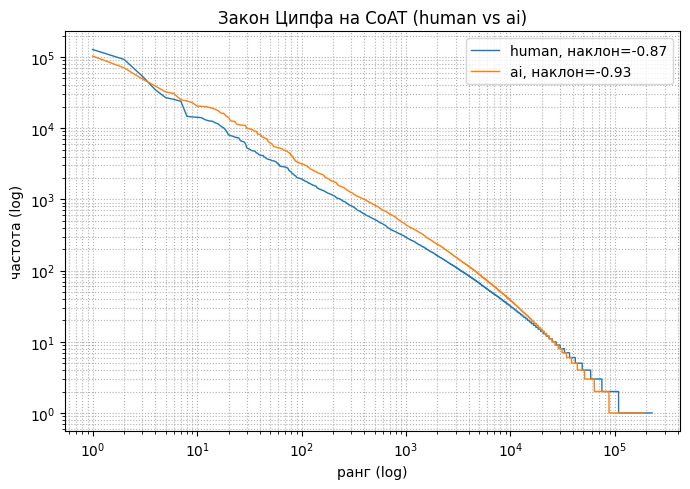

In [5]:
plt.figure(figsize=(7, 5))
for name, freq, color in [('human', human_freq, 'C0'), ('ai', ai_freq, 'C1')]:
    counts = np.array([c for _, c in freq.most_common()])
    ranks  = np.arange(1, len(counts) + 1)
    mask   = (ranks >= 10) & (ranks <= 5000)
    b, a   = np.polyfit(np.log10(ranks[mask]), np.log10(counts[mask]), 1)
    plt.loglog(ranks, counts, lw=1, color=color, label=f'{name}, наклон={b:.2f}')
plt.xlabel('ранг (log)')
plt.ylabel('частота (log)')
plt.title('Закон Ципфа на CoAT (human vs ai)')
plt.legend(); plt.grid(True, which='both', ls=':'); plt.tight_layout()
plt.show()

## 4. Закон Хипса по классам

human: V = 5.67 * N^0.728
ai   : V = 8.86 * N^0.670


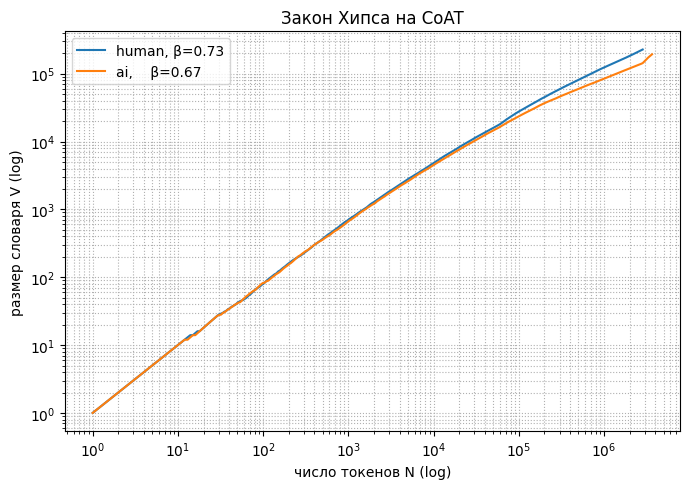

In [6]:
def vocab_growth(token_lists, n_points=300):
    all_toks = []
    for t in token_lists:
        all_toks.extend(t)
    n = len(all_toks)
    sample = np.unique(np.geomspace(1, n, num=n_points).astype(np.int64))
    sample_set = set(sample.tolist())
    seen, xs, ys = set(), [], []
    for i, w in enumerate(all_toks, 1):
        seen.add(w)
        if i in sample_set:
            xs.append(i); ys.append(len(seen))
    if not xs or xs[-1] != n:
        xs.append(n); ys.append(len(seen))
    return np.array(xs), np.array(ys)

human_lists = [t for t, l in zip(train_tokens, train_labels) if l == 0]
ai_lists    = [t for t, l in zip(train_tokens, train_labels) if l == 1]

xs_h, ys_h = vocab_growth(human_lists)
xs_a, ys_a = vocab_growth(ai_lists)

def fit_heaps(xs, ys, min_n=1000):
    m = xs >= min_n
    b, lk = np.polyfit(np.log10(xs[m]), np.log10(ys[m]), 1)
    return 10**lk, b

K_h, b_h = fit_heaps(xs_h, ys_h)
K_a, b_a = fit_heaps(xs_a, ys_a)
print(f'human: V = {K_h:.2f} * N^{b_h:.3f}')
print(f'ai   : V = {K_a:.2f} * N^{b_a:.3f}')

plt.figure(figsize=(7, 5))
plt.loglog(xs_h, ys_h, lw=1.5, color='C0', label=f'human, β={b_h:.2f}')
plt.loglog(xs_a, ys_a, lw=1.5, color='C1', label=f'ai,    β={b_a:.2f}')
plt.xlabel('число токенов N (log)')
plt.ylabel('размер словаря V (log)')
plt.title('Закон Хипса на CoAT')
plt.legend(); plt.grid(True, which='both', ls=':'); plt.tight_layout()
plt.show()

## 5. Биграммы по классам

In [7]:
def count_bigrams(token_lists):
    bg = Counter()
    for t in token_lists:
        if len(t) < 2:
            continue
        bg.update(zip(t, t[1:]))
    return bg

h_bg = count_bigrams(human_lists)
a_bg = count_bigrams(ai_lists)
print(f'unique bigrams human: {len(h_bg):,}')
print(f'unique bigrams ai:    {len(a_bg):,}\n')

print('Топ-15 биграмм (human):')
for (w1, w2), c in h_bg.most_common(15):
    print(f'  {w1+" "+w2:<22}{c:>9,}')
print('\nТоп-15 биграмм (ai):')
for (w1, w2), c in a_bg.most_common(15):
    print(f'  {w1+" "+w2:<22}{c:>9,}')

unique bigrams human: 1,474,962
unique bigrams ai:    1,525,949

Топ-15 биграмм (human):
  в году                    6,505
  российской федерации      3,724
  а также                   2,937
  в том                     2,464
  в соответствии            2,121
  и в                       2,069
  соответствии с            1,887
  об этом                   1,862
  том числе                 1,781
  на территории             1,699
  в рамках                  1,519
  муниципального района     1,441
  из за                     1,410
  что в                     1,388
  и не                      1,376

Топ-15 биграмм (ai):
  а также                   5,183
  о том                     4,584
  российской федерации      3,912
  в году                    3,000
  в этом                    2,999
  я не                      2,779
  во время                  2,767
  в том                     2,672
  об этом                   2,574
  на территории             2,510
  в рамках                  2,301
  том

## 6. Характерные слова для каждого класса

Для каждого слова с частотой не менее 20 в корпусе ранжируем по отношению относительных частот

In [8]:
def char_words(fa, fb, top=20, min_count=20):
    na, nb = sum(fa.values()), sum(fb.values())
    rows = []
    for w, ca in fa.items():
        if ca < min_count:
            continue
        cb = fb.get(w, 0)
        rows.append((w, ca, cb, (ca/na) / ((cb+1)/nb)))
    rows.sort(key=lambda r: r[3], reverse=True)
    return rows[:top]

def show(rows, title):
    print(title)
    print(f'  {"word":<20}{"in A":>8}{"in B":>8}{"score":>8}')
    for w, ca, cb, s in rows:
        print(f'  {w:<20}{ca:>8,}{cb:>8,}{s:>8.2f}')

show(char_words(human_freq, ai_freq), '== Характерные слова для HUMAN (vs AI) ==')
print()
show(char_words(ai_freq, human_freq), '== Характерные слова для AI (vs HUMAN) ==')

== Характерные слова для HUMAN (vs AI) ==
  word                    in A    in B   score
  расовый                   66       0   84.97
  афроамериканцы            46       0   59.22
  гавайцы                   33       0   42.48
  испаноязычные             33       0   42.48
  оставшейся                32       0   41.20
  неактивных                31       0   39.91
  взвод                     30       0   38.62
  любимского                29       0   37.34
  азиатов                   29       0   37.34
  неактивными               55       1   35.40
  коих                      26       0   33.47
  уезду                     23       0   29.61
  саткинского               23       0   29.61
  верхнетоемский            23       0   29.61
  азиаты                    44       1   28.32
  паевого                   22       0   28.32
  яп                        44       1   28.32
  мошенского                22       0   28.32
  зрт                       21       0   27.04
  испано          

## 7. Морфологическая обработка: Snowball-стемминг для русского

NLTK Porter заточен под английский, поэтому для русского используем NLTK SnowballStemmer('russian')

In [9]:
stemmer = SnowballStemmer('russian')
all_words = set(human_freq) | set(ai_freq)
stem_map = {w: stemmer.stem(w) for w in all_words}

def apply_stem(freq):
    out = Counter()
    for w, c in freq.items():
        out[stem_map[w]] += c
    return out

human_stem = apply_stem(human_freq)
ai_stem    = apply_stem(ai_freq)

print(f'{"version":<18}{"# tokens":>14}{"# types":>12}{"reduction":>14}')
for name, orig, stemmed in [('human', human_freq, human_stem), ('ai', ai_freq, ai_stem)]:
    nt = sum(orig.values())
    print(f'{name+" original":<18}{nt:>14,}{len(orig):>12,}')
    print(f'{name+" stemmed":<18}{nt:>14,}{len(stemmed):>12,}{(1-len(stemmed)/len(orig))*100:>13.1f}%')

version                 # tokens     # types     reduction
human original         2,836,164     226,805
human stemmed          2,836,164      90,298         60.2%
ai original            3,651,332     192,641
ai stemmed             3,651,332      85,915         55.4%


## 8. Naive Bayes класификатор на униграммах


Документ предсказываем как ai, если sum(w in doc) s(w) > 0, иначе как human. Это эквивалентно Naive Bayes с равномерным априором

In [10]:
ALPHA = 1.0
n_h = sum(human_freq.values())
n_a = sum(ai_freq.values())
V   = len(all_words)

log_score = {}
for w in all_words:
    log_score[w] = (
        math.log((ai_freq.get(w, 0)    + ALPHA) / (n_a + ALPHA*V)) -
        math.log((human_freq.get(w, 0) + ALPHA) / (n_h + ALPHA*V))
    )

top_ai    = sorted(log_score.items(), key=lambda x: -x[1])[:15]
top_human = sorted(log_score.items(), key=lambda x:  x[1])[:15]
print('Сильнее всего тянут предсказание в сторону AI:')
for w, s in top_ai:
    print(f'  {w:<20}{s:>8.2f}')
print('\nСильнее всего тянут предсказание в сторону HUMAN:')
for w, s in top_human:
    print(f'  {w:<20}{s:>8.2f}')

Сильнее всего тянут предсказание в сторону AI:
  оригинал                5.14
  хотябы                  4.63
  фоторепортаж            4.31
  скачать                 4.16
  акб                     4.07
  тч                      4.05
  нажмите                 4.05
  новороссии              3.99
  программасулакшина      3.81
  подробнее               3.77
  анисимов                3.68
  блога                   3.66
  прессслужба             3.64
  обязательна             3.63
  прессслужбы             3.53

Сильнее всего тянут предсказание в сторону HUMAN:
  расовый                -4.43
  афроамериканцы         -4.08
  испаноязычные          -3.76
  гавайцы                -3.76
  оставшейся             -3.73
  неактивных             -3.70
  взвод                  -3.66
  азиатов                -3.63
  любимского             -3.63
  неактивными            -3.56
  коих                   -3.53
  уезду                  -3.41
  верхнетоемский         -3.41
  саткинского            -3.41
  п

In [11]:
t0 = time.time()
preds = np.array([
    1 if sum(log_score.get(w, 0.0) for w in t) > 0 else 0
    for t in val_tokens
])
print(f'оценено за {time.time()-t0:.1f}s\n')

acc  = (preds == val_labels).mean()
tp   = ((preds==1) & (val_labels==1)).sum()
tn   = ((preds==0) & (val_labels==0)).sum()
fp   = ((preds==1) & (val_labels==0)).sum()
fn   = ((preds==0) & (val_labels==1)).sum()
prec = tp/(tp+fp); rec = tp/(tp+fn); f1 = 2*prec*rec/(prec+rec)

print(f'val accuracy: {acc:.4f}')
print(f'TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}')
print(f'precision={prec:.3f}  recall={rec:.3f}  F1={f1:.3f}')
print('\n(случайный baseline ~ 0.50, классы сбалансированы 50/50)')

оценено за 0.1s

val accuracy: 0.6603
TP=7,997  TN=8,266  FP=4,048  FN=4,317
precision=0.664  recall=0.649  F1=0.657

(случайный baseline ~ 0.50, классы сбалансированы 50/50)


## 9. Выводы

1. AI-тексты в CoAT в среднем длиннее человеческих (около 42 vs 33 токена), но используют заметно меньше уникальных слов

2. Закон Ципфа выполняется в обоих классах с близкими наклонами; разница в наклоне сама по себе диагностически слабая

3. Закон Хипса показывает чуть меньший показатель β у ИИ — рост словаря медленнее, что согласуется с большей повторяемостью

4. Биграммы и характерные слова показывают разный лексический профиль: ИИ к стандартным фразам, человеческие тексты — к разнообразной именованной и доменной лексике

5. Простейший классификатор Naive Bayes на униграммах даёт около 66% accuracy на валидации против 50% случайного baseline